# Software Development Lifecycle using Lang-Graph

In [1]:
import sys
print(sys.executable)

c:\Github\SDLC-using-Lang-Graph\env\Scripts\python.exe


In [2]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_openai import ChatOpenAI

In [ ]:
llm = ChatOpenAI(
    model = "gpt-4.1-mini",
    temperature = 0.5
)

In [7]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.types import Command, interrupt
import datetime

In [8]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id" : "9"}}

In [9]:
import sys
from pathlib import Path

# Go up one directory from "testing grounds" to the project root
project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [10]:
from tools.implementor import create_file, update_file

In [11]:
tools = [create_file, update_file]

In [12]:
implementor = llm.bind_tools(tools = tools)

def implementing_agent(state:State):
    response = implementor.invoke(state["messages"])
    return {"messages": [response]}

In [13]:
graph_builder = StateGraph(State)

graph_builder.add_node("Implementor", implementing_agent)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_edge(START, "Implementor")
graph_builder.add_conditional_edges(
    "Implementor",
    tools_condition
)
graph_builder.add_edge("tools", "Implementor")

graph = graph_builder.compile(checkpointer=memory)

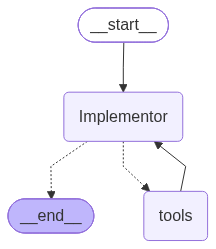

In [14]:
graph

In [16]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content="Implement this idea: I want to build a  tic tac toe game" \
    "which runs on webpages. I want the  game to follow general tic tac toe  rules " \
    "and  should display the score of the session and should be  refresed to 0-0 when  " \
    "a new session is made. The players should be able to name themselves. The scores of the game" \
    "should also be stored, you are free  to choose how they are stored."),
    
]},config=config
)

Writing code into agent_testing_grounds/workspace\style.css......
Writing code into agent_testing_grounds/workspace\index.html......
Code succesfully written into agent_testing_grounds/workspace\style.css
Code succesfully written into agent_testing_grounds/workspace\index.html
Writing code into agent_testing_grounds/workspace\script.js......
Code succesfully written into agent_testing_grounds/workspace\script.js


In [17]:
for m  in response["messages"]:
    m.pretty_print()

================================ Human Message =================================


================================== Ai Message ==================================

Hello! How can I assist you today? If you have any questions or need help with something, feel free to ask.
================================ Human Message =================================

Implement this idea: I want to build a  tic tac toe gamewhich runs on webpages. I want the  game to follow general tic tac toe  rules and  should display the score of the session and should be  refresed to 0-0 when  a new session is made. The players should be able to name themselves. The scores of the gameshould also be stored, you are free  to choose how they are stored.
================================== Ai Message ==================================
Tool Calls:
  create_file (call_FkMrYN3CRTghU99SXq0biDAG)
 Call ID: call_FkMrYN3CRTghU99SXq0biDAG
  Args:
    file: index.html
    code: <!DOCTYPE html>
<html lang="en">
<head>
    <meta c

In [19]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content="Implement  this  idea: In the application you  just  built i want  you  " \
    "to add  another feature/update. You can see  that the user is only  able to play 1 game " \
    "and  then they  either create  a  new session or they click on start  game and sscore resets to " \
    "0 - 0. I want you to replace the start gae button with next game button and still keep the scores" \
    "visible  once the necxt game button is clicked"),
    
]},config=config
)

BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_XSOgQdTVNjUqYIlmjwaBaFmi", 'type': 'invalid_request_error', 'param': 'messages.[11].role', 'code': None}}